# Low-Rank Approximation for Image Compression Using SVD

### Numerical Linear Algebra Project 5

---

> This notebook studies low-rank approximation methods for image compression. We represent images as matrices and use truncated singular value decomposition to reconstruct images with different ranks and we evaluate the results qualitatively through visual comparison and quantitatively using Frobenius error, energy retention, storage ratio, PSNR, and SSIM.
---

A grayscale image is represented as a matrix

$$
A \in \mathbb{R}^{m \times n}.
$$

The singular value decomposition is

$$
A = U \Sigma V^T.
$$

The rank-k truncated SVD approximation is

$$
A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T.
$$

For this approximation,

$$
\operatorname{rank}(A_k) \leq k,
$$

$$
\|A - A_k\|_2 = \sigma_{k+1},
$$

$$
\|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{r} \sigma_i^2},
$$

and

$$
A_k = \arg\min_{\operatorname{rank}(B) \leq k} \|A - B\|_F.
$$

For a grayscale image, the original storage cost is

$$
mn.
$$

A rank-k SVD representation stores $k$ left singular vectors, $k$ right singular vectors, and $k$ singular values:

$$
k(m+n+1).
$$

The storage ratio is therefore

$$
\frac{k(m+n+1)}{mn}.
$$

For RGB images, we apply SVD separately to the red, green, and blue channels.

## Importing Libraries




In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity
from skimage.metrics import peak_signal_noise_ratio
from sklearn.utils.extmath import randomized_svd

warnings.simplefilter(action="ignore", category=FutureWarning)

start_time = time.time()

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
np.set_printoptions(precision=4, suppress=True)

print("Libraries loaded.")

Libraries loaded.


## Reading Data

The data are importing from [Kaggle](https://www.kaggle.com/datasets/arnaud58/landscape-pictures):

- landscapes (900 pictures)
- landscapes montain (900 pictures)
- landscapes desert (100 pictures)
- landscapes sea (500 pictures)
- landscapes beach (500 pictures)
- landscapes island (500 pictures)
- landscapes japan (900 pictures)

The image files are in the folder `archive/`

*Search recursively for common image formats and fail early with a clear message if the dataset folder is missing or empty.*

In [2]:
def find_image_files(data_dir):
    """Find image files recursively under data_dir."""
    data_dir = Path(data_dir)
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    if not data_dir.exists():
        raise FileNotFoundError(
            f"Directory {data_dir} does not exist. "
            "Place the downloaded Kaggle image dataset in archive/."
        )

    image_paths = sorted(
        path for path in data_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in valid_extensions
    )

    if len(image_paths) == 0:
        raise FileNotFoundError(
            f"No image files were found in {data_dir}. "
            "Expected extensions: .jpg, .jpeg, .png, .bmp, .webp."
        )

    print(f"Number of images found: {len(image_paths)}")
    print("First few image paths:")
    for path in image_paths[:5]:
        print(f"  {path}")

    return image_paths

Use the project-relative archive folder so the notebook can be run by anybody

In [4]:
DATA_DIR = Path("archive")
if not DATA_DIR.exists():
    fallback_dir = Path.home() / "Downloads" / "archive"
    if fallback_dir.exists():
        DATA_DIR = fallback_dir
        print(f"Using fallback image directory: {DATA_DIR}")

image_files = find_image_files(DATA_DIR)

Using fallback image directory: /Users/attiliopittelli/Downloads/archive
Number of images found: 4319
First few image paths:
  /Users/attiliopittelli/Downloads/archive/00000000.jpg
  /Users/attiliopittelli/Downloads/archive/00000000_(2).jpg
  /Users/attiliopittelli/Downloads/archive/00000000_(3).jpg
  /Users/attiliopittelli/Downloads/archive/00000000_(4).jpg
  /Users/attiliopittelli/Downloads/archive/00000000_(5).jpg


## ETL Process for Data

The helper functions below load images, preserve aspect ratio, resize large files to a manageable size, normalize pixels to `[0, 1]`, and display arrays consistently.

*ETL*: Extract, Transform, Load

In [5]:
def _thumbnail_resample_filter():
    """Return a Pillow resampling filter that works across Pillow versions."""
    if hasattr(Image, "Resampling"):
        return Image.Resampling.LANCZOS
    return Image.LANCZOS


def load_grayscale_image(path, max_size=(512, 512)):
    """Load an image as a normalized grayscale matrix."""
    path = Path(path)
    with Image.open(path) as img:
        img = img.convert("L")
        img.thumbnail(max_size, _thumbnail_resample_filter())
        A = np.asarray(img, dtype=np.float64) / 255.0
    return A


def load_rgb_image(path, max_size=(512, 512)):
    """Load an image as a normalized RGB array."""
    path = Path(path)
    with Image.open(path) as img:
        img = img.convert("RGB")
        img.thumbnail(max_size, _thumbnail_resample_filter())
        rgb_array = np.asarray(img, dtype=np.float64) / 255.0
    return rgb_array


def display_image_array(A, title="", cmap=None):
    """Display a grayscale or RGB image array."""
    A_display = np.clip(A, 0, 1)
    if A_display.ndim == 2 and cmap is None:
        cmap = "gray"

    plt.figure(figsize=(6, 5))
    plt.imshow(A_display, cmap=cmap, vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

Load the first image as a grayscale matrix and inspect its dimensions and numerical range.

Image path: /Users/attiliopittelli/Downloads/archive/00000000.jpg
Matrix shape: (512, 512)
Min pixel value: 0.0196
Max pixel value: 1.0000
Numerical rank: 512


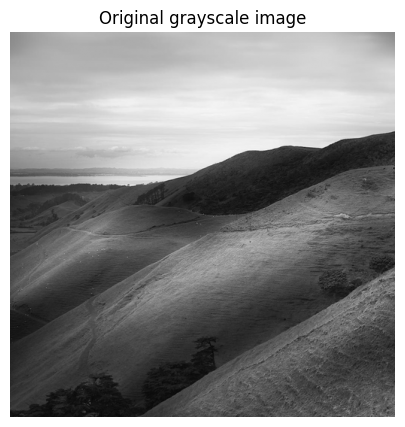

In [6]:
image_path = image_files[0]
A = load_grayscale_image(image_path)

print(f"Image path: {image_path}")
print(f"Matrix shape: {A.shape}")
print(f"Min pixel value: {A.min():.4f}")
print(f"Max pixel value: {A.max():.4f}")
print(f"Numerical rank: {np.linalg.matrix_rank(A)}")

assert A.ndim == 2, "The grayscale image should be a matrix."
assert np.all((A >= 0) & (A <= 1)), "Pixel values should be normalized to [0, 1]."

display_image_array(A, title="Original grayscale image")

### --Get stats

Compute compact descriptive statistics for the image matrix before fitting any *low-rank model*.

In [7]:
def analyze_image_matrix(A):
    """Return basic numerical summaries for an image matrix."""
    A = np.asarray(A)
    return {
        "shape": A.shape,
        "number of pixels": int(A.size),
        "min": float(np.min(A)),
        "max": float(np.max(A)),
        "mean": float(np.mean(A)),
        "median": float(np.median(A)),
        "standard deviation": float(np.std(A)),
        "numerical rank": int(np.linalg.matrix_rank(A)),
        "Frobenius norm": float(np.linalg.norm(A, ord="fro")),
    }


image_stats = analyze_image_matrix(A)
for key, value in image_stats.items():
    print(f"{key}: {value}")

shape: (512, 512)
number of pixels: 262144
min: 0.0196078431372549
max: 1.0
mean: 0.4676869411094516
median: 0.3803921568627451
standard deviation: 0.27273987425347657
numerical rank: 512
Frobenius norm: 277.19876415334267


---

## Build Baseline Models

The main baseline model stores the economy SVD of the image matrix once, meaning that different *rank-k* reconstructions can then be formed cheaply by keeping only the first $k$ singular triplets.

### --SVD Model Class

For visual purposes only the reconstructed pixels are clipped to `[0, 1]`. For Frobenius-error validation, the class also exposes the raw truncated SVD approximation before clipping.

In [8]:
class LowRankSVD:
    def __init__(self):
        self.U = None
        self.s = None
        self.Vt = None
        self.shape = None
        self.rank = None

    def fit(self, A):
        A = np.asarray(A, dtype=np.float64)
        if A.ndim != 2:
            raise ValueError("LowRankSVD expects a 2D matrix.")

        self.shape = A.shape
        self.U, self.s, self.Vt = np.linalg.svd(A, full_matrices=False)
        self.rank = int(np.linalg.matrix_rank(A))
        return self

    def _check_is_fitted(self):
        if self.U is None or self.s is None or self.Vt is None:
            raise ValueError("The model must be fitted before reconstruction.")

    def _validate_k(self, k):
        self._check_is_fitted()
        max_rank = len(self.s)
        if not isinstance(k, (int, np.integer)):
            raise TypeError("k must be an integer.")
        if k < 1 or k > max_rank:
            raise ValueError(f"k must be between 1 and {max_rank}.")
        return int(k)

    def reconstruct_raw(self, k):
        k = self._validate_k(k)
        return (self.U[:, :k] * self.s[:k]) @ self.Vt[:k, :]

    def reconstruct(self, k):
        return np.clip(self.reconstruct_raw(k), 0, 1)

    def relative_frobenius_error(self, A, k):
        A = np.asarray(A, dtype=np.float64)
        A_k = self.reconstruct_raw(k)
        return np.linalg.norm(A - A_k, ord="fro") / np.linalg.norm(A, ord="fro")

    def relative_frobenius_error_from_singular_values(self, k):
        k = self._validate_k(k)
        tail_energy = np.sum(self.s[k:] ** 2)
        total_energy = np.sum(self.s ** 2)
        return np.sqrt(tail_energy / total_energy)

    def energy_retained(self, k):
        k = self._validate_k(k)
        return np.sum(self.s[:k] ** 2) / np.sum(self.s ** 2)

    def storage_ratio(self, k):
        k = self._validate_k(k)
        m, n = self.shape
        return k * (m + n + 1) / (m * n)

    def compression_factor(self, k):
        return 1 / self.storage_ratio(k)

Fit the baseline model once and inspect the leading singular values.

In [9]:
svd_model = LowRankSVD()
svd_model.fit(A)

print(f"Shape: {svd_model.shape}")
print(f"Numerical rank: {svd_model.rank}")
print("First 10 singular values:")
print(svd_model.s[:10])

Shape: (512, 512)
Numerical rank: 512
First 10 singular values:
[268.7599  46.8123  31.4715  23.5354  11.3368  10.0821   9.6242   7.3295
   7.0279   5.5944]



---
## Set Rank

Choose a grid of candidate ranks and ranks larger than the smaller image dimension are removed automatically

In [10]:
k_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
k_values = [k for k in k_values if k <= min(A.shape)]

main_k = 50
main_k = min(main_k, min(A.shape))

print(f"Selected ranks: {k_values}")
print(f"Main rank used for focused experiments: {main_k}")

Selected ranks: [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
Main rank used for focused experiments: 50


## Initial Analysis - Grayscale Image

The first analysis compares rank-k reconstructions of the selected grayscale image.

### --Run Truncated SVD

Display the original image next to several low-rank approximations. Each title reports the rank, retained energy, and storage ratio.

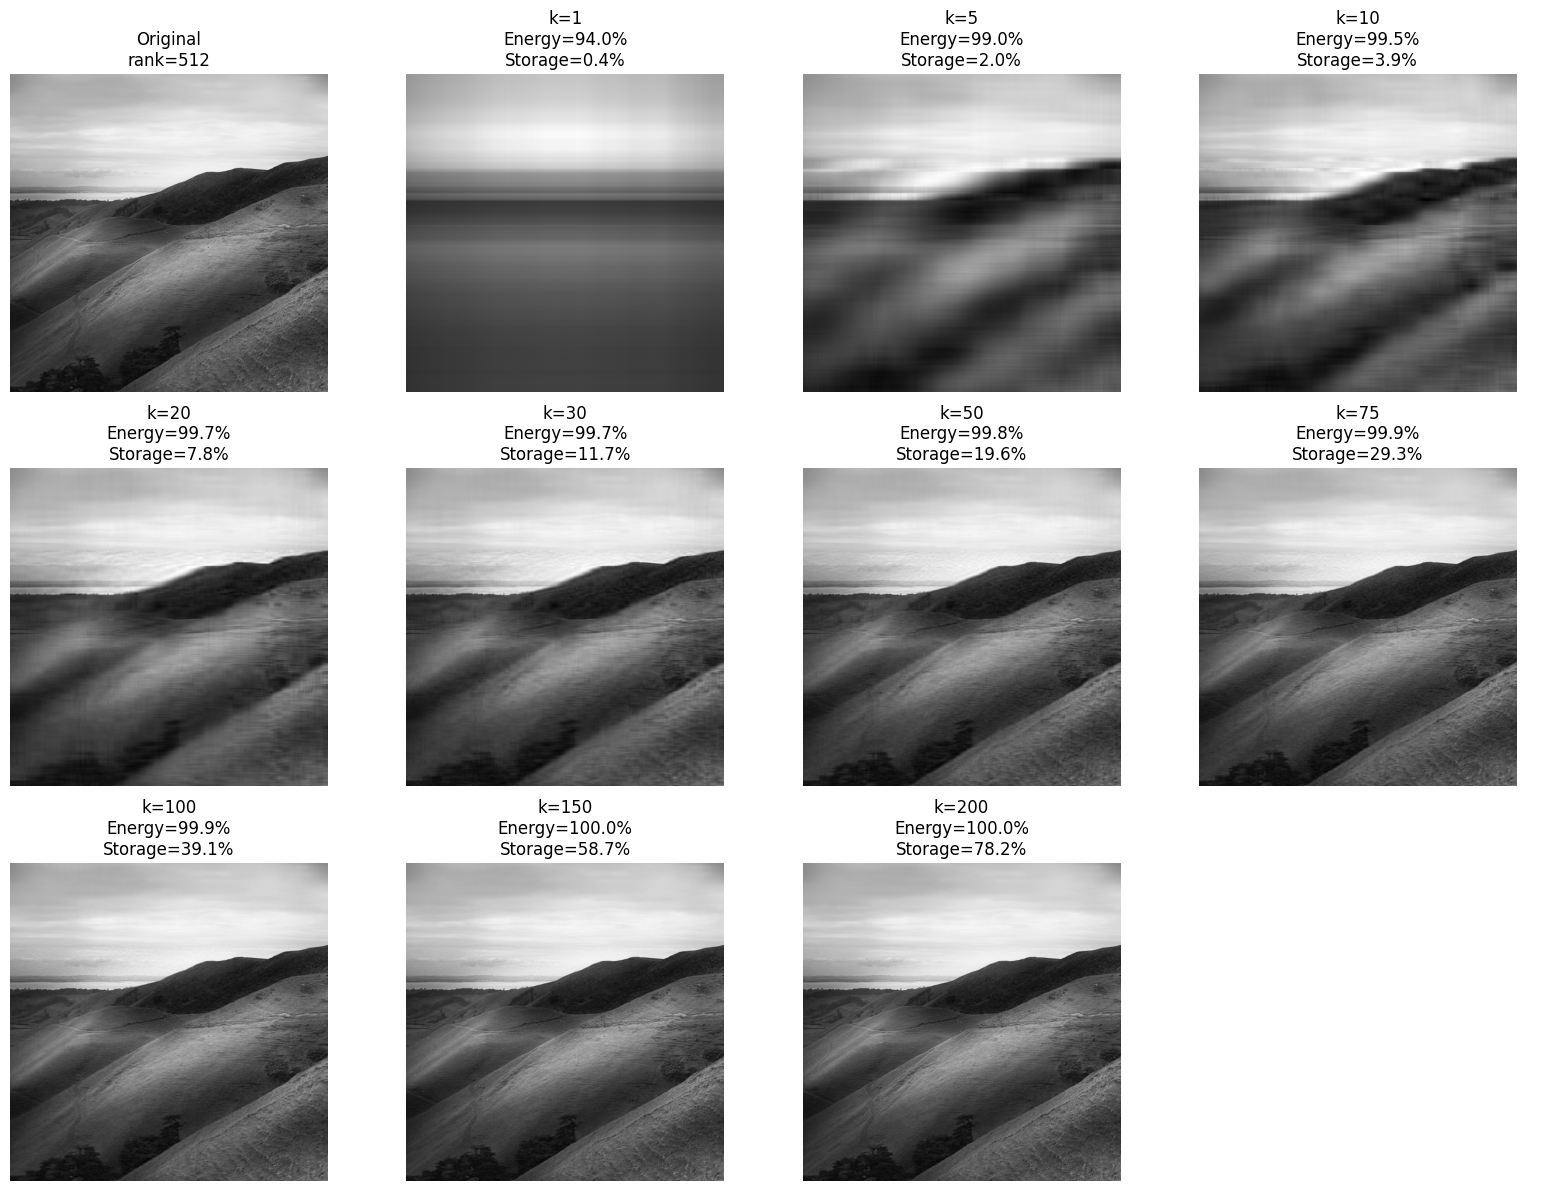

Displayed 10 rank-k reconstructions.


In [11]:
def plot_rank_reconstructions(A, model, ranks, ncols=4):
    """Plot the original image and rank-k reconstructions."""
    ranks = list(ranks)
    n_images = len(ranks) + 1
    nrows = int(np.ceil(n_images / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.asarray(axes).ravel()

    axes[0].imshow(A, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Original\nrank={np.linalg.matrix_rank(A)}")
    axes[0].axis("off")

    for ax, k in zip(axes[1:], ranks):
        A_k = model.reconstruct(k)
        energy = 100 * model.energy_retained(k)
        storage = 100 * model.storage_ratio(k)
        ax.imshow(A_k, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"k={k}\nEnergy={energy:.1f}%\nStorage={storage:.1f}%")
        ax.axis("off")

    for ax in axes[n_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Displayed {len(ranks)} rank-k reconstructions.")


plot_rank_reconstructions(A, svd_model, k_values)

### --Singular Value Decay

Singular value decay explains why some images admit strong low-rank approximations. Fast decay means fewer singular vectors capture most of the matrix energy.

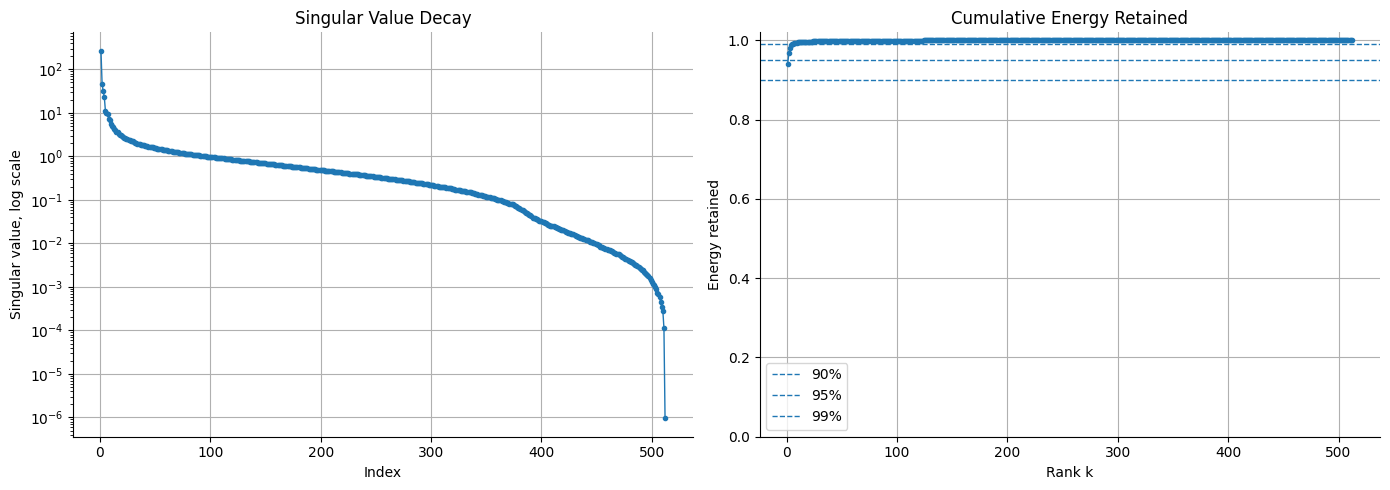

Energy retained at k=50: 0.9982


In [12]:
singular_values = svd_model.s
cumulative_energy = np.cumsum(singular_values ** 2) / np.sum(singular_values ** 2)
rank_axis = np.arange(1, len(singular_values) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(rank_axis, singular_values, marker="o", markersize=3, linewidth=1)
axes[0].set_title("Singular Value Decay")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Singular value, log scale")

axes[1].plot(rank_axis, cumulative_energy, marker="o", markersize=3, linewidth=1)
for threshold in [0.90, 0.95, 0.99]:
    axes[1].axhline(threshold, linestyle="--", linewidth=1, label=f"{threshold:.0%}")
axes[1].set_title("Cumulative Energy Retained")
axes[1].set_xlabel("Rank k")
axes[1].set_ylabel("Energy retained")
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Energy retained at k={main_k}: {svd_model.energy_retained(main_k):.4f}")

### --Quantitative Metrics

Compute numerical quality metrics for each selected rank. Frobenius error is evaluated on the raw SVD approximation to match the theoretical formula; PSNR and SSIM use clipped pixel values.

In [13]:
def safe_ssim(original, reconstructed, channel_axis=None):
    """Compute SSIM with a valid window size for small images."""
    min_side = min(original.shape[:2])
    if min_side < 3:
        return np.nan

    kwargs = {"data_range": 1.0, "channel_axis": channel_axis}
    if min_side < 7:
        win_size = min_side if min_side % 2 == 1 else min_side - 1
        kwargs["win_size"] = max(win_size, 3)

    return structural_similarity(original, reconstructed, **kwargs)


def compute_metrics_table(A, model, k_values):
    """Compute grayscale reconstruction metrics for each rank."""
    rows = []
    for k in k_values:
        A_k = model.reconstruct(k)
        rows.append({
            "k": int(k),
            "relative Frobenius error": model.relative_frobenius_error(A, k),
            "relative Frobenius error from singular values": model.relative_frobenius_error_from_singular_values(k),
            "energy retained": model.energy_retained(k),
            "storage ratio": model.storage_ratio(k),
            "compression factor": model.compression_factor(k),
            "PSNR": peak_signal_noise_ratio(A, A_k, data_range=1.0),
            "SSIM": safe_ssim(A, A_k),
        })
    return pd.DataFrame(rows)

Build and display the metric table.

In [14]:
metrics_df = compute_metrics_table(A, svd_model, k_values)
display(metrics_df.round({
    "relative Frobenius error": 6,
    "relative Frobenius error from singular values": 6,
    "energy retained": 4,
    "storage ratio": 4,
    "compression factor": 2,
    "PSNR": 2,
    "SSIM": 4,
}))

,k,relative Frobenius error,relative Frobenius error from singular values,energy retained,storage ratio,compression factor,PSNR,SSIM
0,1,0.244867,0.244867,0.9400,0.0039,255.75,17.55,0.6000
1,5,0.098332,0.098332,0.9903,0.0196,51.15,25.48,0.6773
2,10,0.073427,0.073427,0.9946,0.0391,25.58,28.02,0.7133
3,20,0.058820,0.058820,0.9965,0.0782,12.79,29.94,0.7533
4,30,0.051538,0.051538,0.9973,0.1173,8.53,31.09,0.7894
5,50,0.042547,0.042547,0.9982,0.1955,5.12,32.75,0.8429
6,75,0.034923,0.034923,0.9988,0.2933,3.41,34.47,0.8870
7,100,0.029089,0.029089,0.9992,0.3910,2.56,36.05,0.9174
8,150,0.020136,0.020136,0.9996,0.5865,1.71,39.25,0.9564
9,200,0.013552,0.013552,0.9998,0.7820,1.28,42.69,0.9782


Plot the main rank-quality and rank-storage trade-offs.

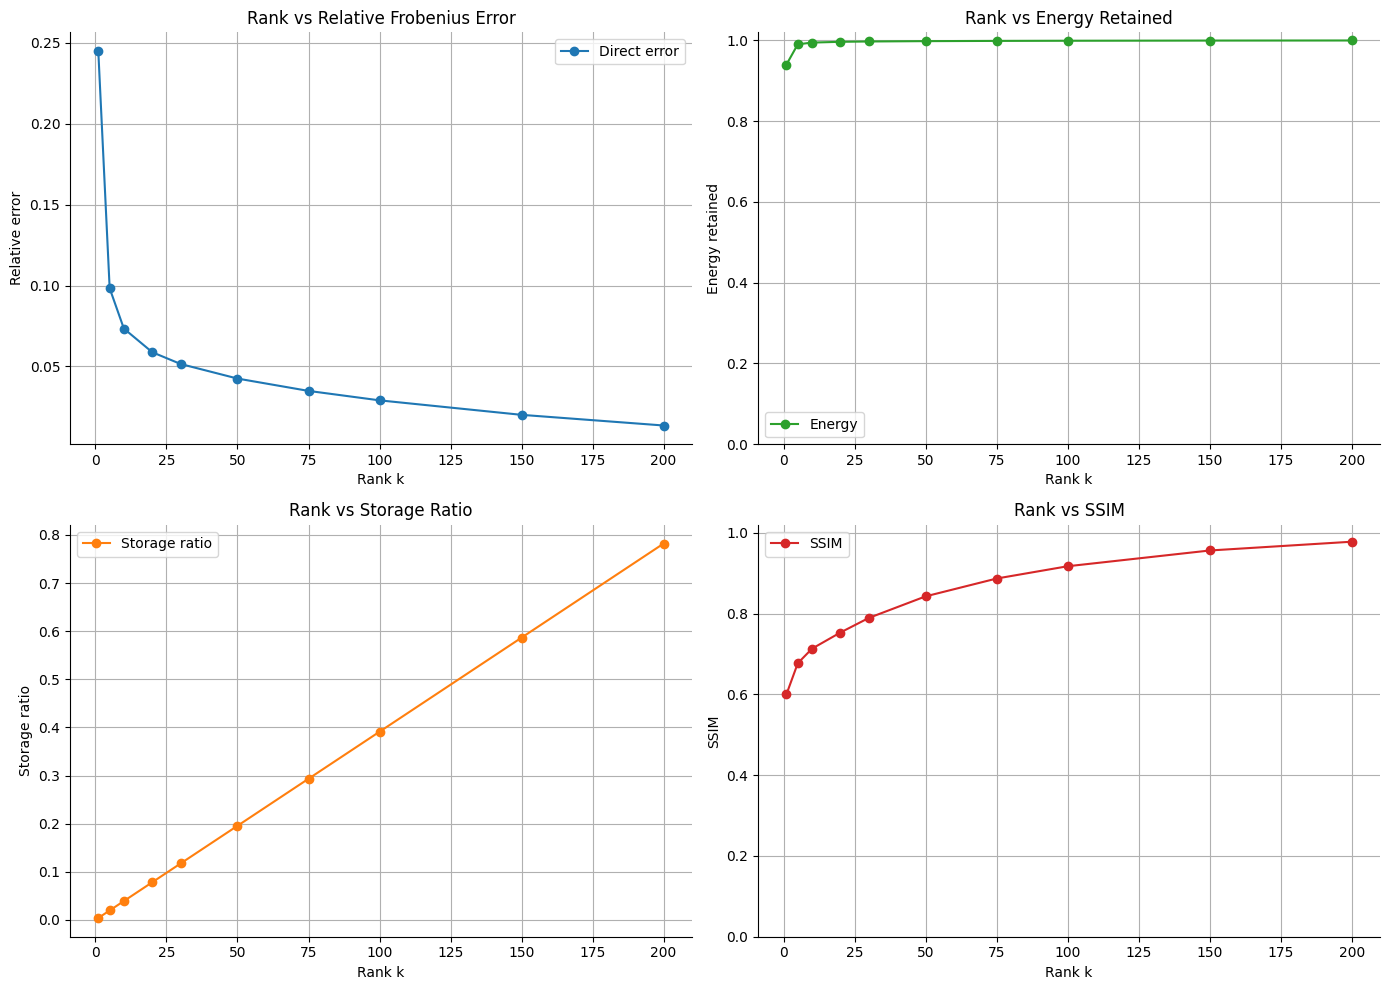

In [15]:
def plot_grayscale_metrics(metrics_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    axes[0].plot(metrics_df["k"], metrics_df["relative Frobenius error"], marker="o", label="Direct error")
    axes[0].set_title("Rank vs Relative Frobenius Error")
    axes[0].set_xlabel("Rank k")
    axes[0].set_ylabel("Relative error")
    axes[0].legend()

    axes[1].plot(metrics_df["k"], metrics_df["energy retained"], marker="o", color="tab:green", label="Energy")
    axes[1].set_title("Rank vs Energy Retained")
    axes[1].set_xlabel("Rank k")
    axes[1].set_ylabel("Energy retained")
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()

    axes[2].plot(metrics_df["k"], metrics_df["storage ratio"], marker="o", color="tab:orange", label="Storage ratio")
    axes[2].set_title("Rank vs Storage Ratio")
    axes[2].set_xlabel("Rank k")
    axes[2].set_ylabel("Storage ratio")
    axes[2].legend()

    axes[3].plot(metrics_df["k"], metrics_df["SSIM"], marker="o", color="tab:red", label="SSIM")
    axes[3].set_title("Rank vs SSIM")
    axes[3].set_xlabel("Rank k")
    axes[3].set_ylabel("SSIM")
    axes[3].set_ylim(0, 1.02)
    axes[3].legend()

    plt.tight_layout()
    plt.show()


plot_grayscale_metrics(metrics_df)

### --Validation

The Eckart-Young-Mirsky theorem predicts that the Frobenius reconstruction error can be computed from discarded singular values. The next cell checks that the direct computation and singular-value formula agree numerically.

In [16]:
validation_differences = []
shape_checks = []

for k in k_values:
    error_direct = svd_model.relative_frobenius_error(A, k)
    error_singular_values = svd_model.relative_frobenius_error_from_singular_values(k)
    validation_differences.append(abs(error_direct - error_singular_values))
    shape_checks.append(svd_model.reconstruct(k).shape == A.shape)

max_difference = max(validation_differences)
print(f"Maximum absolute difference: {max_difference:.12e}")
print(f"All reconstruction shapes match original shape: {all(shape_checks)}")

assert max_difference < 1e-8, "Direct and singular-value Frobenius errors should agree."
assert all(shape_checks), "Every reconstruction should have the same shape as the original image."

Maximum absolute difference: 8.659739592076e-15
All reconstruction shapes match original shape: True


## Interpretation

### --Interpretation

Small k captures the dominant global structure of the image. Larger k adds edges, texture, and local detail.

Smooth images are usually more compressible because their singular values decay faster. Highly textured images require more singular values before the approximation preserves fine structure.

The central trade-off is between storage ratio and visual or numerical quality. Use the computed plots and tables above to decide which rank is acceptable for this image.

## Initial Analysis - RGB Image

For RGB images, SVD is applied independently to the red, green, and blue channel matrices. The RGB storage ratio is

$$
\frac{3k(m+n+1)}{3mn} = \frac{k(m+n+1)}{mn}.
$$

Load the same file as an RGB image and display it.

RGB image shape: (512, 512, 3)
Min pixel value: 0.0000
Max pixel value: 1.0000


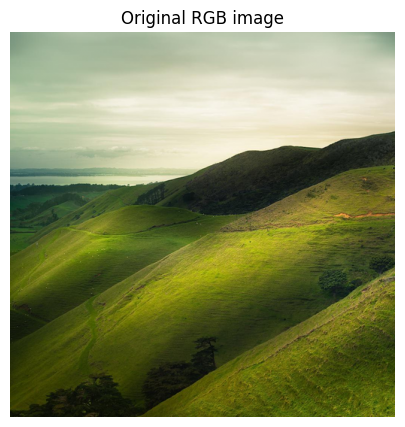

In [17]:
RGB = load_rgb_image(image_path)

print(f"RGB image shape: {RGB.shape}")
print(f"Min pixel value: {RGB.min():.4f}")
print(f"Max pixel value: {RGB.max():.4f}")

assert RGB.ndim == 3 and RGB.shape[2] == 3, "RGB image should have three channels."
assert np.all((RGB >= 0) & (RGB <= 1)), "Pixel values should be normalized to [0, 1]."

display_image_array(RGB, title="Original RGB image")

Define channel-wise RGB compression utilities. The requested `compress_rgb_image` function fits one SVD model per channel and returns the reconstructed RGB image plus the fitted channel models.

In [18]:
def fit_rgb_svd_models(rgb_array):
    """Fit one LowRankSVD model per RGB channel."""
    if rgb_array.ndim != 3 or rgb_array.shape[2] != 3:
        raise ValueError("Expected an RGB array with shape (m, n, 3).")
    return [LowRankSVD().fit(rgb_array[:, :, channel]) for channel in range(3)]


def reconstruct_rgb_from_models(models, k):
    """Reconstruct an RGB image from pre-fitted channel models."""
    channels = [model.reconstruct(k) for model in models]
    return np.clip(np.stack(channels, axis=2), 0, 1)


def reconstruct_rgb_raw_from_models(models, k):
    """Return the raw, unclipped channel-wise RGB reconstruction."""
    channels = [model.reconstruct_raw(k) for model in models]
    return np.stack(channels, axis=2)


def compress_rgb_image(rgb_array, k):
    """Compress an RGB image by applying rank-k SVD to each channel."""
    models = fit_rgb_svd_models(rgb_array)
    compressed_rgb = reconstruct_rgb_from_models(models, k)
    return compressed_rgb, models

Fit the RGB channel models once for repeated experiments.

In [19]:
rgb_models = fit_rgb_svd_models(RGB)
print("Fitted SVD models for red, green, and blue channels.")
for name, model in zip(["Red", "Green", "Blue"], rgb_models):
    print(f"{name} channel rank: {model.rank}")

Fitted SVD models for red, green, and blue channels.
Red channel rank: 512
Green channel rank: 512
Blue channel rank: 512


Display RGB reconstructions across the selected rank grid.

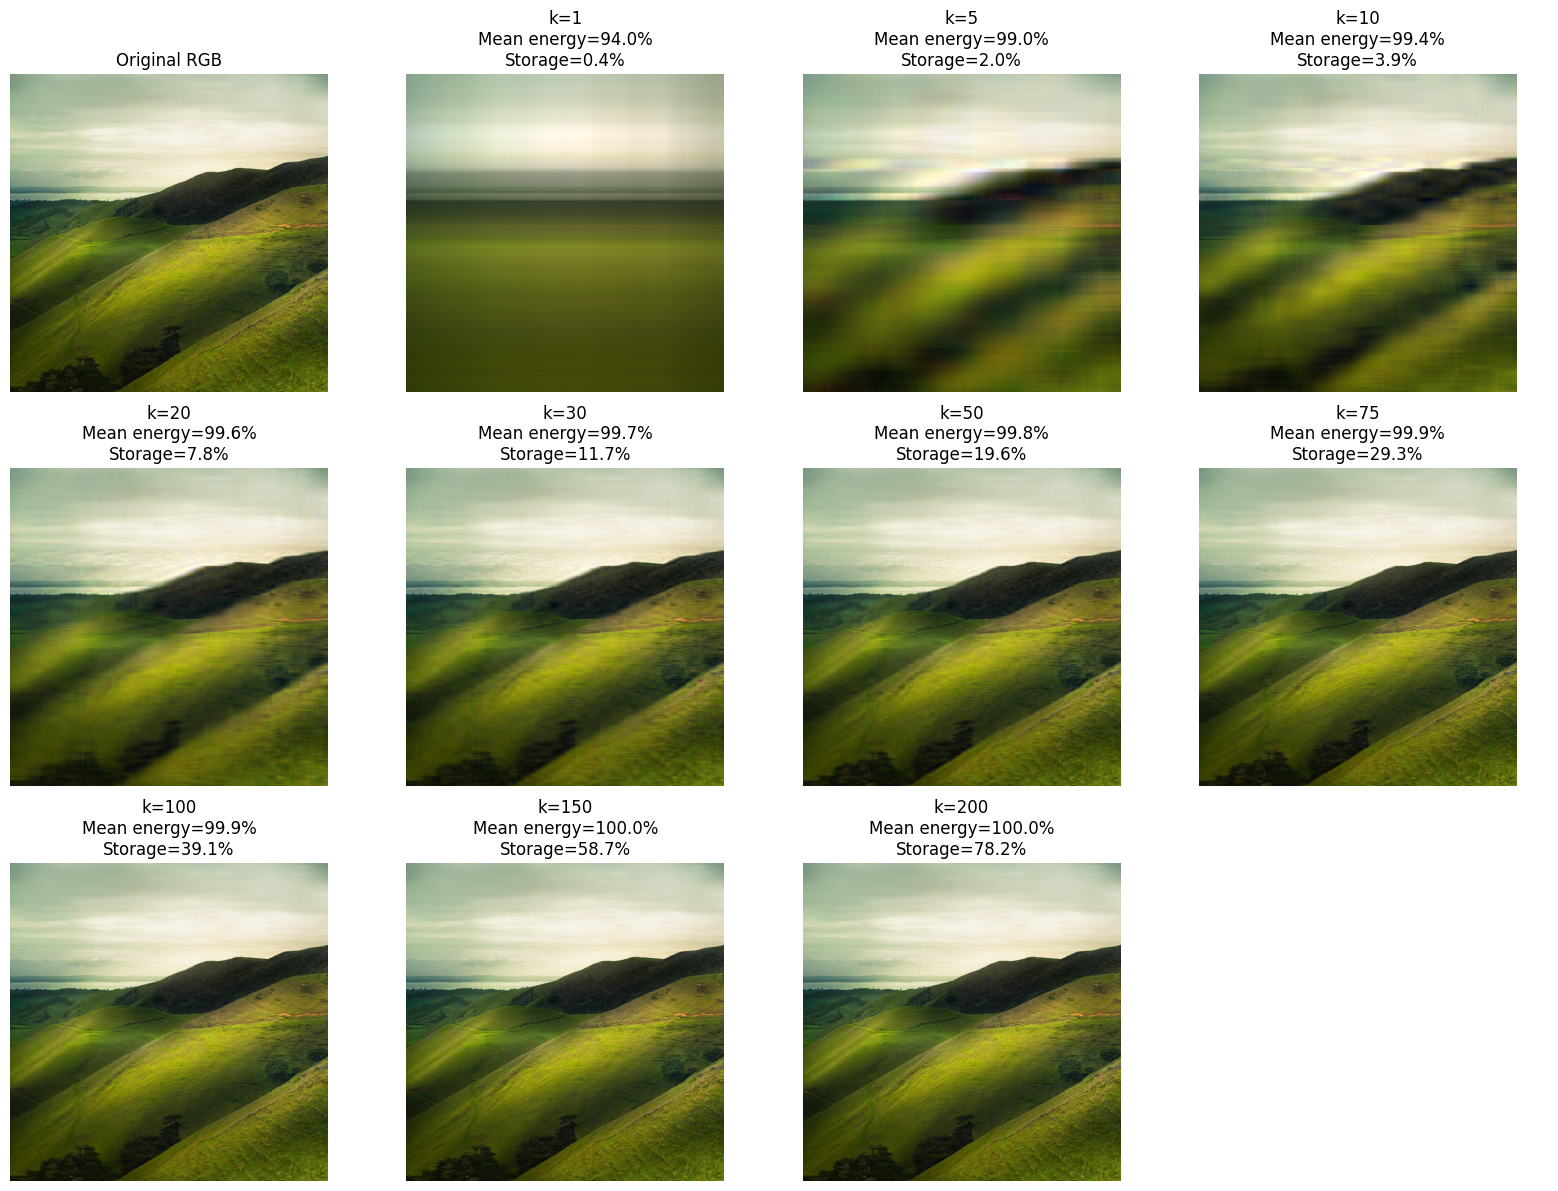

In [20]:
def plot_rgb_reconstructions(rgb_array, models, ranks, ncols=4):
    ranks = list(ranks)
    n_images = len(ranks) + 1
    nrows = int(np.ceil(n_images / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.asarray(axes).ravel()

    axes[0].imshow(np.clip(rgb_array, 0, 1))
    axes[0].set_title("Original RGB")
    axes[0].axis("off")

    m, n, _ = rgb_array.shape
    for ax, k in zip(axes[1:], ranks):
        rgb_k = reconstruct_rgb_from_models(models, k)
        mean_energy = np.mean([model.energy_retained(k) for model in models])
        storage = k * (m + n + 1) / (m * n)
        ax.imshow(rgb_k)
        ax.set_title(f"k={k}\nMean energy={100 * mean_energy:.1f}%\nStorage={100 * storage:.1f}%")
        ax.axis("off")

    for ax in axes[n_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_rgb_reconstructions(RGB, rgb_models, k_values)

Compute RGB metrics by measuring error over all three channels and SSIM with `channel_axis=-1`.

In [21]:
def compute_rgb_metrics_table(rgb_array, models, k_values):
    """Compute RGB reconstruction metrics for each rank."""
    m, n, _ = rgb_array.shape
    rows = []

    for k in k_values:
        rgb_k_raw = reconstruct_rgb_raw_from_models(models, k)
        rgb_k = np.clip(rgb_k_raw, 0, 1)
        storage_ratio = k * (m + n + 1) / (m * n)

        rows.append({
            "k": int(k),
            "relative Frobenius error": np.linalg.norm(rgb_array - rgb_k_raw) / np.linalg.norm(rgb_array),
            "storage ratio": storage_ratio,
            "compression factor": 1 / storage_ratio,
            "PSNR": peak_signal_noise_ratio(rgb_array, rgb_k, data_range=1.0),
            "SSIM": safe_ssim(rgb_array, rgb_k, channel_axis=-1),
        })

    return pd.DataFrame(rows)


rgb_metrics_df = compute_rgb_metrics_table(RGB, rgb_models, k_values)
display(rgb_metrics_df.round({
    "relative Frobenius error": 6,
    "storage ratio": 4,
    "compression factor": 2,
    "PSNR": 2,
    "SSIM": 4,
}))

,k,relative Frobenius error,storage ratio,compression factor,PSNR,SSIM
0,1,0.248521,0.0039,255.75,17.79,0.6028
1,5,0.100019,0.0196,51.15,25.70,0.6778
2,10,0.075309,0.0391,25.58,28.17,0.7126
3,20,0.060652,0.0782,12.79,30.04,0.7527
4,30,0.053189,0.1173,8.53,31.18,0.7880
5,50,0.043873,0.1955,5.12,32.85,0.8411
6,75,0.035986,0.2933,3.41,34.58,0.8857
7,100,0.029982,0.3910,2.56,36.16,0.9166
8,150,0.020807,0.5865,1.71,39.34,0.9559
9,200,0.014044,0.7820,1.28,42.76,0.9779


Plot RGB quality and storage metrics over rank.

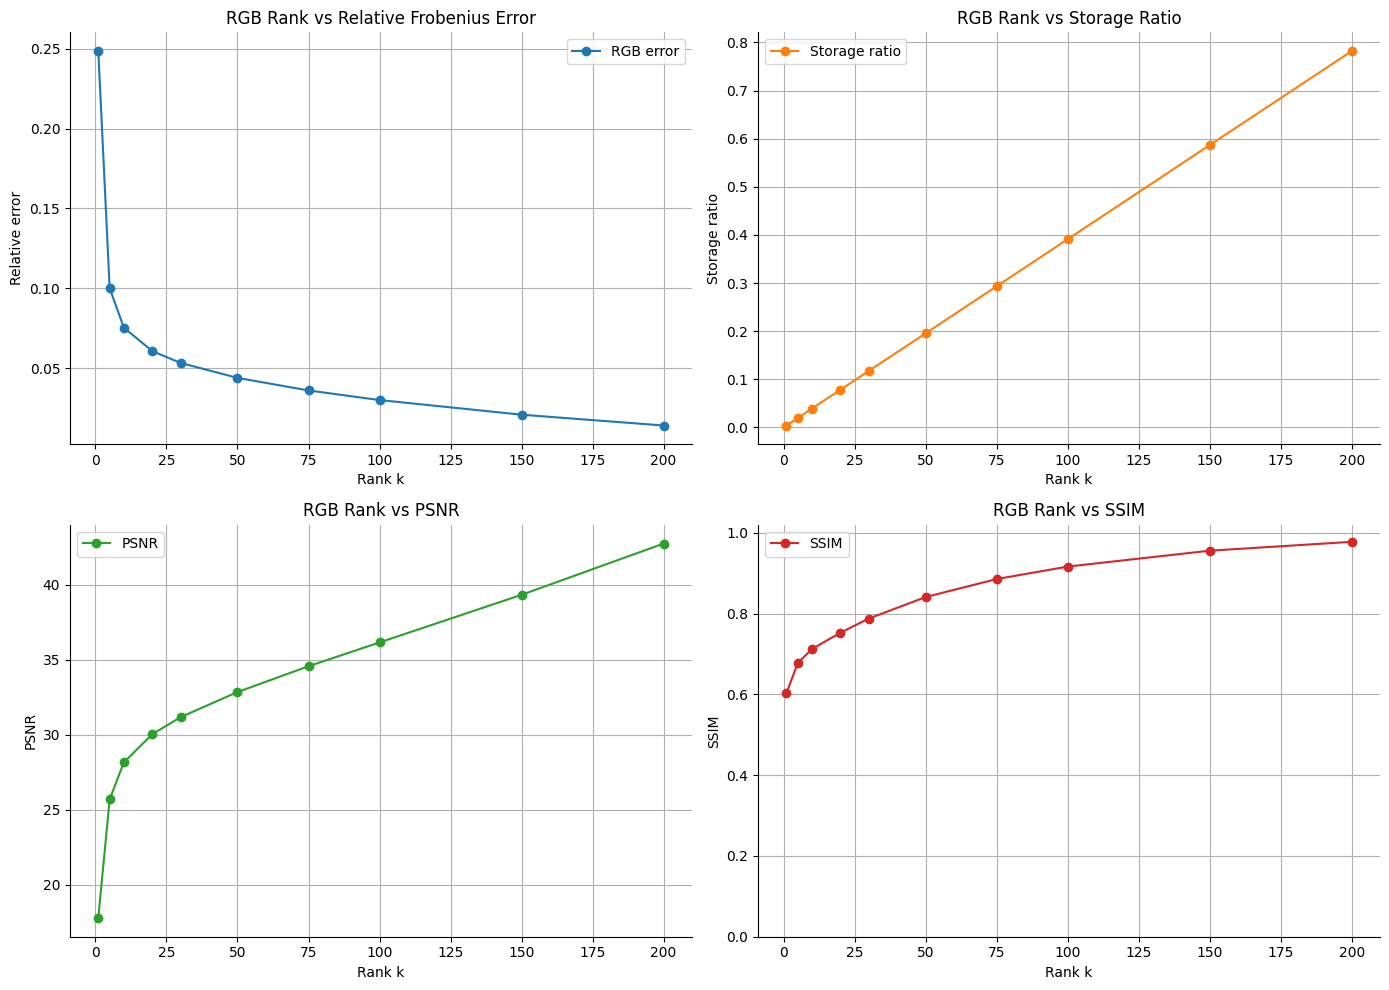

In [22]:
def plot_rgb_metrics(rgb_metrics_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    axes[0].plot(rgb_metrics_df["k"], rgb_metrics_df["relative Frobenius error"], marker="o", label="RGB error")
    axes[0].set_title("RGB Rank vs Relative Frobenius Error")
    axes[0].set_xlabel("Rank k")
    axes[0].set_ylabel("Relative error")
    axes[0].legend()

    axes[1].plot(rgb_metrics_df["k"], rgb_metrics_df["storage ratio"], marker="o", color="tab:orange", label="Storage ratio")
    axes[1].set_title("RGB Rank vs Storage Ratio")
    axes[1].set_xlabel("Rank k")
    axes[1].set_ylabel("Storage ratio")
    axes[1].legend()

    axes[2].plot(rgb_metrics_df["k"], rgb_metrics_df["PSNR"], marker="o", color="tab:green", label="PSNR")
    axes[2].set_title("RGB Rank vs PSNR")
    axes[2].set_xlabel("Rank k")
    axes[2].set_ylabel("PSNR")
    axes[2].legend()

    axes[3].plot(rgb_metrics_df["k"], rgb_metrics_df["SSIM"], marker="o", color="tab:red", label="SSIM")
    axes[3].set_title("RGB Rank vs SSIM")
    axes[3].set_xlabel("Rank k")
    axes[3].set_ylabel("SSIM")
    axes[3].set_ylim(0, 1.02)
    axes[3].legend()

    plt.tight_layout()
    plt.show()


plot_rgb_metrics(rgb_metrics_df)

## Classical SVD vs Randomized SVD

Full SVD computes all singular vectors. Randomized SVD estimates only a low-dimensional singular subspace, which can be faster for large matrices and moderate k.

Implement a randomized rank-k approximation using `sklearn.utils.extmath.randomized_svd`.

In [23]:
def randomized_rank_k_approximation(A, k, random_state=42):
    """Compute a rank-k randomized SVD approximation."""
    U_random, s_random, Vt_random = randomized_svd(
        A,
        n_components=k,
        random_state=random_state,
    )
    return (U_random * s_random) @ Vt_random

Compare reconstruction runtime and quality for the full-SVD model and randomized SVD.

In [25]:
comparison_k_values = [10, 20, 50, 100]
comparison_k_values = [k for k in comparison_k_values if k <= min(A.shape)]

comparison_rows = []
for k in comparison_k_values:
    classical_start = time.time()
    A_k_classical_raw = svd_model.reconstruct_raw(k)
    A_k_classical = np.clip(A_k_classical_raw, 0, 1)
    classical_time = time.time() - classical_start

    randomized_start = time.time()
    A_k_randomized_raw = randomized_rank_k_approximation(A, k, random_state=42)
    A_k_randomized = np.clip(A_k_randomized_raw, 0, 1)
    randomized_time = time.time() - randomized_start

    comparison_rows.append({
        "k": int(k),
        "classical_time": classical_time,
        "randomized_time": randomized_time,
        "classical_relative_error": np.linalg.norm(A - A_k_classical_raw, ord="fro") / np.linalg.norm(A, ord="fro"),
        "randomized_relative_error": np.linalg.norm(A - A_k_randomized_raw, ord="fro") / np.linalg.norm(A, ord="fro"),
        "classical_psnr": peak_signal_noise_ratio(A, A_k_classical, data_range=1.0),
        "randomized_psnr": peak_signal_noise_ratio(A, A_k_randomized, data_range=1.0),
        "classical_ssim": safe_ssim(A, A_k_classical),
        "randomized_ssim": safe_ssim(A, A_k_randomized),
    })

svd_comparison_df = pd.DataFrame(comparison_rows)
display(svd_comparison_df.round({
    "classical_time": 6,
    "randomized_time": 6,
    "classical_relative_error": 6,
    "randomized_relative_error": 6,
    "classical_psnr": 2,
    "randomized_psnr": 2,
    "classical_ssim": 4,
    "randomized_ssim": 4,
}))

,k,classical_time,randomized_time,classical_relative_error,randomized_relative_error,classical_psnr,randomized_psnr,classical_ssim,randomized_ssim
0,10,0.001934,0.006398,0.073427,0.073427,28.02,28.02,0.7133,0.7133
1,20,0.001255,0.004459,0.058820,0.058820,29.94,29.94,0.7533,0.7533
2,50,0.000713,0.009749,0.042547,0.042561,32.75,32.75,0.8429,0.8427
3,100,0.001486,0.013392,0.029089,0.029192,36.05,36.02,0.9174,0.9168


Plot the accuracy, runtime, and SSIM comparison between classical and randomized SVD.

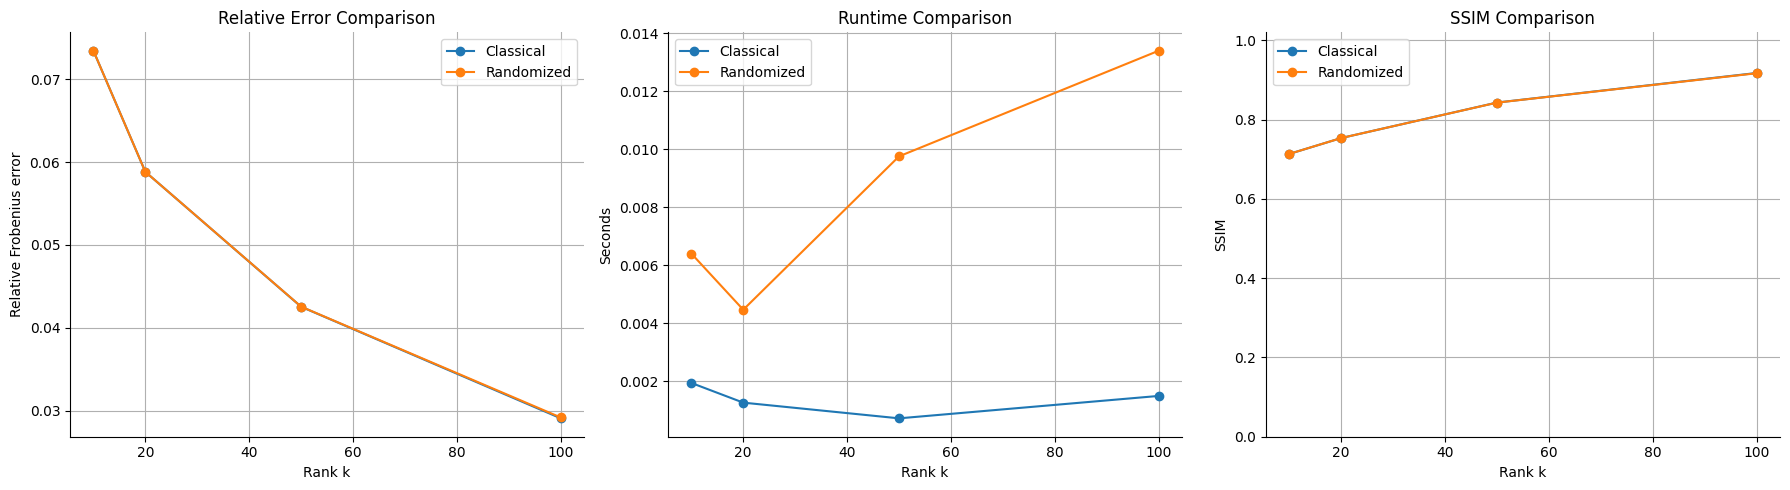

In [26]:
def plot_svd_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(comparison_df["k"], comparison_df["classical_relative_error"], marker="o", label="Classical")
    axes[0].plot(comparison_df["k"], comparison_df["randomized_relative_error"], marker="o", label="Randomized")
    axes[0].set_title("Relative Error Comparison")
    axes[0].set_xlabel("Rank k")
    axes[0].set_ylabel("Relative Frobenius error")
    axes[0].legend()

    axes[1].plot(comparison_df["k"], comparison_df["classical_time"], marker="o", label="Classical")
    axes[1].plot(comparison_df["k"], comparison_df["randomized_time"], marker="o", label="Randomized")
    axes[1].set_title("Runtime Comparison")
    axes[1].set_xlabel("Rank k")
    axes[1].set_ylabel("Seconds")
    axes[1].legend()

    axes[2].plot(comparison_df["k"], comparison_df["classical_ssim"], marker="o", label="Classical")
    axes[2].plot(comparison_df["k"], comparison_df["randomized_ssim"], marker="o", label="Randomized")
    axes[2].set_title("SSIM Comparison")
    axes[2].set_xlabel("Rank k")
    axes[2].set_ylabel("SSIM")
    axes[2].set_ylim(0, 1.02)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_svd_comparison(svd_comparison_df)

### --Interpretation

Randomized SVD may be faster for large matrices and moderate k, but can be slightly less accurate than full SVD. Runtime differences may be small for smaller images because the full SVD has already been computed and classical reconstruction only forms the rank-k product.

## Stability Experiments

In this section we test rank stability: how reconstruction error, retained energy, storage, and SSIM change as the rank increases.

### --Rank Stability Test

The test reports threshold ranks for common energy and SSIM targets.

In [27]:
def first_rank_reaching(df, column, threshold):
    """Return the first tested rank reaching a threshold, or None."""
    hits = df.loc[df[column] >= threshold, "k"]
    if hits.empty:
        return None
    return int(hits.iloc[0])


def rank_stability_test(A, k_values):
    """Evaluate reconstruction stability over a grid of ranks."""
    model = LowRankSVD().fit(A)
    rows = []

    for k in sorted(set(k_values)):
        if k > min(A.shape):
            continue
        A_k = model.reconstruct(k)
        rows.append({
            "k": int(k),
            "Frobenius error": model.relative_frobenius_error(A, k),
            "energy retained": model.energy_retained(k),
            "storage ratio": model.storage_ratio(k),
            "SSIM": safe_ssim(A, A_k),
        })

    stability_df = pd.DataFrame(rows)
    display(stability_df.round({
        "Frobenius error": 6,
        "energy retained": 4,
        "storage ratio": 4,
        "SSIM": 4,
    }))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(stability_df["k"], stability_df["Frobenius error"], marker="o", label="Error")
    axes[0].set_title("Reconstruction Error Over Rank Levels")
    axes[0].set_xlabel("Rank k")
    axes[0].set_ylabel("Relative Frobenius error")
    axes[0].legend()

    axes[1].plot(stability_df["k"], stability_df["energy retained"], marker="o", color="tab:green", label="Energy")
    axes[1].set_title("Energy Retained Over Rank Levels")
    axes[1].set_xlabel("Rank k")
    axes[1].set_ylabel("Energy retained")
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()

    axes[2].plot(stability_df["k"], stability_df["SSIM"], marker="o", color="tab:red", label="SSIM")
    axes[2].set_title("SSIM Over Rank Levels")
    axes[2].set_xlabel("Rank k")
    axes[2].set_ylabel("SSIM")
    axes[2].set_ylim(0, 1.02)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    for threshold in [0.90, 0.95, 0.99]:
        k_hit = first_rank_reaching(stability_df, "energy retained", threshold)
        print(f"Smallest tested k reaching {threshold:.0%} energy: {k_hit}")

    for threshold in [0.90, 0.95]:
        k_hit = first_rank_reaching(stability_df, "SSIM", threshold)
        if k_hit is None:
            print(f"No tested k reaches SSIM >= {threshold:.2f}.")
        else:
            print(f"Smallest tested k reaching SSIM >= {threshold:.2f}: {k_hit}")

    return stability_df

Run the stability test on a denser rank grid that includes the maximum possible rank.

,k,Frobenius error,energy retained,storage ratio,SSIM
0,1,0.244867,0.9400,0.0039,0.6000
1,5,0.098332,0.9903,0.0196,0.6773
2,10,0.073427,0.9946,0.0391,0.7133
3,14,0.065603,0.9957,0.0547,0.7312
4,20,0.058820,0.9965,0.0782,0.7533
5,27,0.053419,0.9971,0.1056,0.7792
6,30,0.051538,0.9973,0.1173,0.7894
7,40,0.046558,0.9978,0.1564,0.8191
8,50,0.042547,0.9982,0.1955,0.8429
9,53,0.041483,0.9983,0.2072,0.8493


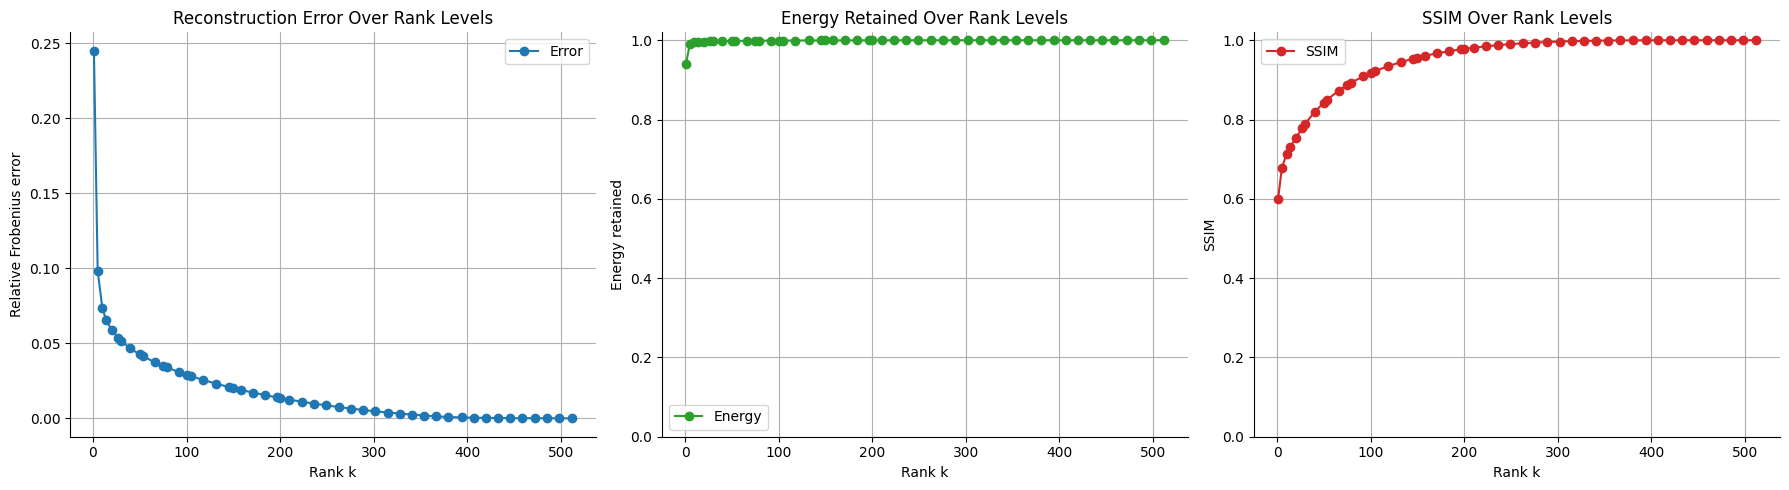

Smallest tested k reaching 90% energy: 1
Smallest tested k reaching 95% energy: 5
Smallest tested k reaching 99% energy: 5
Smallest tested k reaching SSIM >= 0.90: 92
Smallest tested k reaching SSIM >= 0.95: 145


In [28]:
max_rank = min(A.shape)
dense_k_values = sorted(set(k_values + list(np.linspace(1, max_rank, min(40, max_rank), dtype=int))))
stability_df = rank_stability_test(A, dense_k_values)

## Sensitivity Experiments

We now perturb the image with additive Gaussian noise and examine how the rank-k approximation behaves as noise increases.

### --Additive Gaussian Noise

Noise level is scaled relative to the empirical standard deviation of the image.

In [29]:
def add_gaussian_noise(A, alpha, random_state=42):
    """Add clipped Gaussian noise with standard deviation alpha * std(A)."""
    rng = np.random.default_rng(random_state)
    sigma = alpha * np.std(A)
    noise = rng.normal(0, sigma, A.shape)
    return np.clip(A + noise, 0, 1)


def run_noise_injection_experiment(A, k, alphas):
    """Fit SVD to noisy images and evaluate rank-k reconstructions."""
    rows = []

    for alpha in alphas:
        noisy_A = add_gaussian_noise(A, alpha, random_state=42)
        noisy_model = LowRankSVD().fit(noisy_A)
        reconstructed = noisy_model.reconstruct(k)

        rows.append({
            "alpha": float(alpha),
            "error against noisy image": np.linalg.norm(noisy_A - reconstructed, ord="fro") / np.linalg.norm(noisy_A, ord="fro"),
            "error against clean image": np.linalg.norm(A - reconstructed, ord="fro") / np.linalg.norm(A, ord="fro"),
            "PSNR against clean image": peak_signal_noise_ratio(A, reconstructed, data_range=1.0),
            "SSIM against clean image": safe_ssim(A, reconstructed),
        })

    return pd.DataFrame(rows)

Run the noise experiment and display the resulting metrics.

In [30]:
alphas = np.linspace(0.01, 0.40, 20)
noise_df = run_noise_injection_experiment(A, main_k, alphas)

display(noise_df.round({
    "alpha": 3,
    "error against noisy image": 6,
    "error against clean image": 6,
    "PSNR against clean image": 2,
    "SSIM against clean image": 4,
}))

,alpha,error against noisy image,error against clean image,PSNR against clean image,SSIM against clean image
0,0.010,0.042789,0.042607,32.74,0.8422
1,0.031,0.044723,0.043114,32.64,0.8370
2,0.051,0.048357,0.044142,32.43,0.8265
3,0.072,0.053330,0.045686,32.13,0.8107
4,0.092,0.059273,0.047763,31.75,0.7898
5,0.113,0.065878,0.050386,31.28,0.7641
6,0.133,0.072918,0.053510,30.76,0.7341
7,0.154,0.080233,0.057072,30.20,0.7008
8,0.174,0.087710,0.061091,29.61,0.6646
9,0.195,0.095274,0.065448,29.01,0.6269


Plot how noise level affects reconstruction quality.

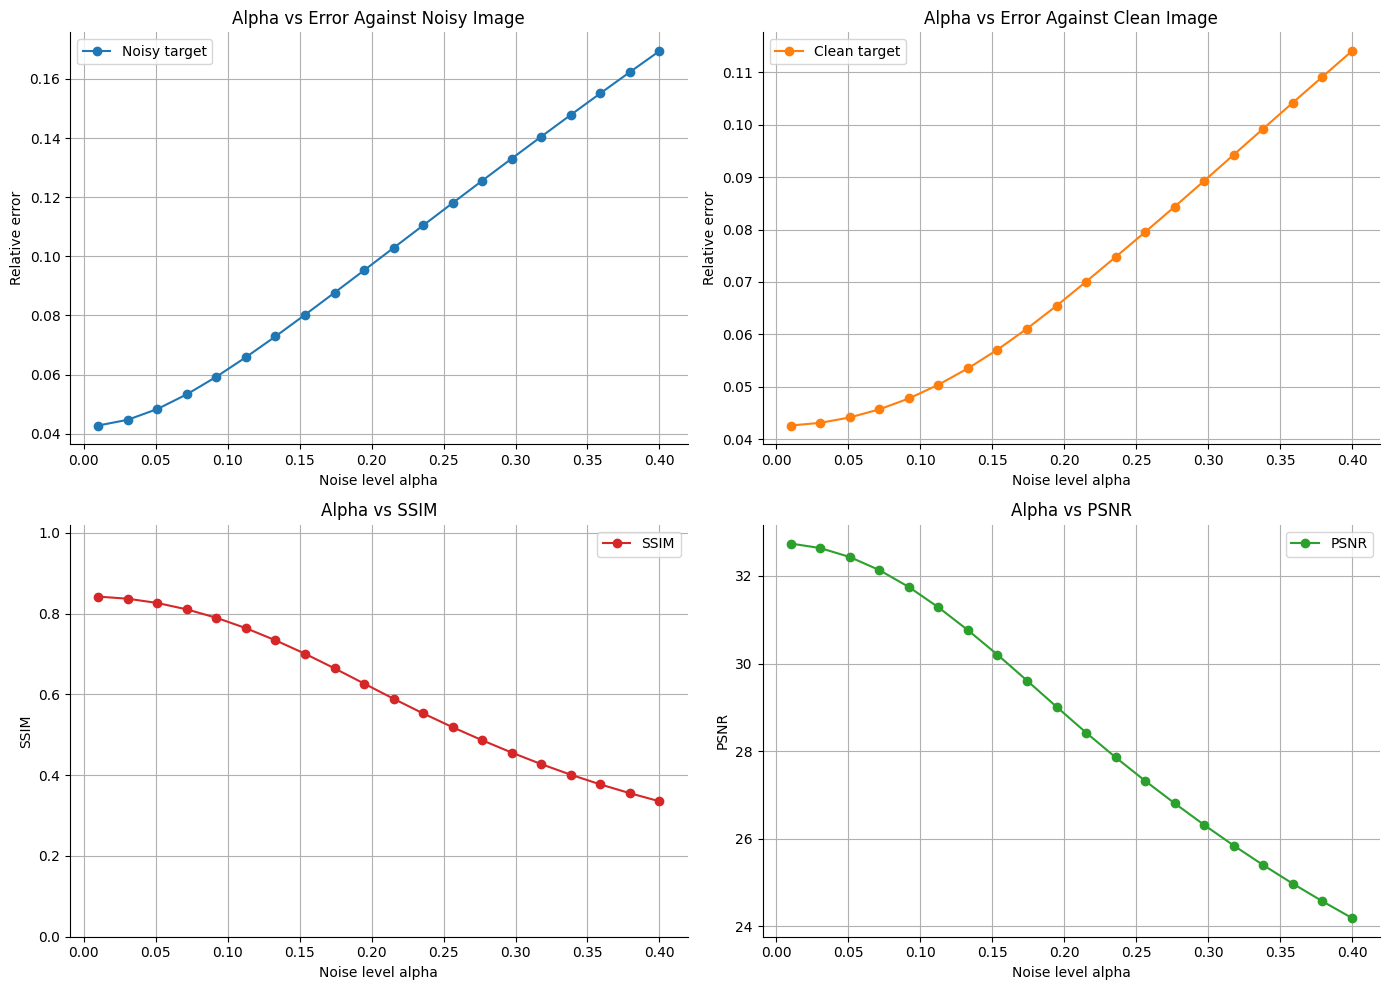

In [31]:
def plot_noise_experiment(noise_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    axes[0].plot(noise_df["alpha"], noise_df["error against noisy image"], marker="o", label="Noisy target")
    axes[0].set_title("Alpha vs Error Against Noisy Image")
    axes[0].set_xlabel("Noise level alpha")
    axes[0].set_ylabel("Relative error")
    axes[0].legend()

    axes[1].plot(noise_df["alpha"], noise_df["error against clean image"], marker="o", color="tab:orange", label="Clean target")
    axes[1].set_title("Alpha vs Error Against Clean Image")
    axes[1].set_xlabel("Noise level alpha")
    axes[1].set_ylabel("Relative error")
    axes[1].legend()

    axes[2].plot(noise_df["alpha"], noise_df["SSIM against clean image"], marker="o", color="tab:red", label="SSIM")
    axes[2].set_title("Alpha vs SSIM")
    axes[2].set_xlabel("Noise level alpha")
    axes[2].set_ylabel("SSIM")
    axes[2].set_ylim(0, 1.02)
    axes[2].legend()

    axes[3].plot(noise_df["alpha"], noise_df["PSNR against clean image"], marker="o", color="tab:green", label="PSNR")
    axes[3].set_title("Alpha vs PSNR")
    axes[3].set_xlabel("Noise level alpha")
    axes[3].set_ylabel("PSNR")
    axes[3].legend()

    plt.tight_layout()
    plt.show()


plot_noise_experiment(noise_df)

### --Interpretation

Low-rank approximation can remove some high-frequency noise because small singular components often contain local variation. If noise becomes too large, the dominant singular vectors start capturing noise as part of the main image structure.

This experiment illustrates both the robustness and the limitations of truncated SVD.

## Multiple Image Experiment

The final empirical check compares rank requirements across up to 20 images from the dataset.

### --Dataset-Level Rank Summary

For each image, compute the ranks needed to retain 90%, 95%, and 99% energy. Also compute numerical rank and, when possible, SSIM and storage ratio at k=50.

In [32]:
def rank_for_energy(model, threshold):
    """Return the smallest rank reaching the target cumulative energy."""
    cumulative = np.cumsum(model.s ** 2) / np.sum(model.s ** 2)
    return int(np.searchsorted(cumulative, threshold) + 1)


def summarize_multiple_images(image_files, max_images=20):
    """Summarize low-rank behavior across several images."""
    rows = []
    selected_files = list(image_files[:max_images])

    for idx, path in enumerate(selected_files, start=1):
        gray = load_grayscale_image(path)
        model = LowRankSVD().fit(gray)
        m, n = gray.shape

        if min(gray.shape) >= 50:
            reconstruction_50 = model.reconstruct(50)
            ssim_at_50 = safe_ssim(gray, reconstruction_50)
            storage_ratio_at_50 = model.storage_ratio(50)
        else:
            ssim_at_50 = np.nan
            storage_ratio_at_50 = np.nan

        rows.append({
            "image": Path(path).name,
            "shape": f"{m} x {n}",
            "numerical rank": model.rank,
            "k_90": rank_for_energy(model, 0.90),
            "k_95": rank_for_energy(model, 0.95),
            "k_99": rank_for_energy(model, 0.99),
            "SSIM at k=50": ssim_at_50,
            "storage ratio at k=50": storage_ratio_at_50,
        })
        print(f"Processed {idx}/{len(selected_files)}: {Path(path).name}")

    return pd.DataFrame(rows)


multi_image_df = summarize_multiple_images(image_files, max_images=20)
display(multi_image_df.round({
    "SSIM at k=50": 4,
    "storage ratio at k=50": 4,
}))

Processed 1/20: 00000000.jpg
Processed 2/20: 00000000_(2).jpg
Processed 3/20: 00000000_(3).jpg
Processed 4/20: 00000000_(4).jpg
Processed 5/20: 00000000_(5).jpg
Processed 6/20: 00000000_(6).jpg
Processed 7/20: 00000000_(7).jpg
Processed 8/20: 00000001.jpg
Processed 9/20: 00000001_(2).jpg
Processed 10/20: 00000001_(3).jpg
Processed 11/20: 00000001_(4).jpg
Processed 12/20: 00000001_(5).jpg
Processed 13/20: 00000001_(6).jpg
Processed 14/20: 00000001_(7).jpg
Processed 15/20: 00000002.jpg
Processed 16/20: 00000002_(2).jpg
Processed 17/20: 00000002_(3).jpg
Processed 18/20: 00000002_(4).jpg
Processed 19/20: 00000002_(5).jpg
Processed 20/20: 00000002_(6).jpg


,image,shape,numerical rank,k_90,k_95,k_99,SSIM at k=50,storage ratio at k=50
0,00000000.jpg,512 x 512,512,1,2,5,0.8429,0.1955
1,00000000_(2).jpg,512 x 512,512,1,2,25,0.8480,0.1955
2,00000000_(3).jpg,386 x 512,386,1,2,15,0.8037,0.2274
3,00000000_(4).jpg,384 x 512,350,1,1,6,0.8316,0.2281
4,00000000_(5).jpg,343 x 512,331,1,1,4,0.9226,0.2437
5,00000000_(6).jpg,275 x 512,275,1,1,25,0.8583,0.2798
6,00000000_(7).jpg,342 x 512,342,1,1,2,0.9326,0.2441
7,00000001.jpg,512 x 512,512,1,1,6,0.8718,0.1955
8,00000001_(2).jpg,512 x 512,512,2,4,35,0.8092,0.1955
9,00000001_(3).jpg,288 x 512,288,1,2,27,0.7805,0.2716


Visualize the distribution of energy-retention ranks across the sample.

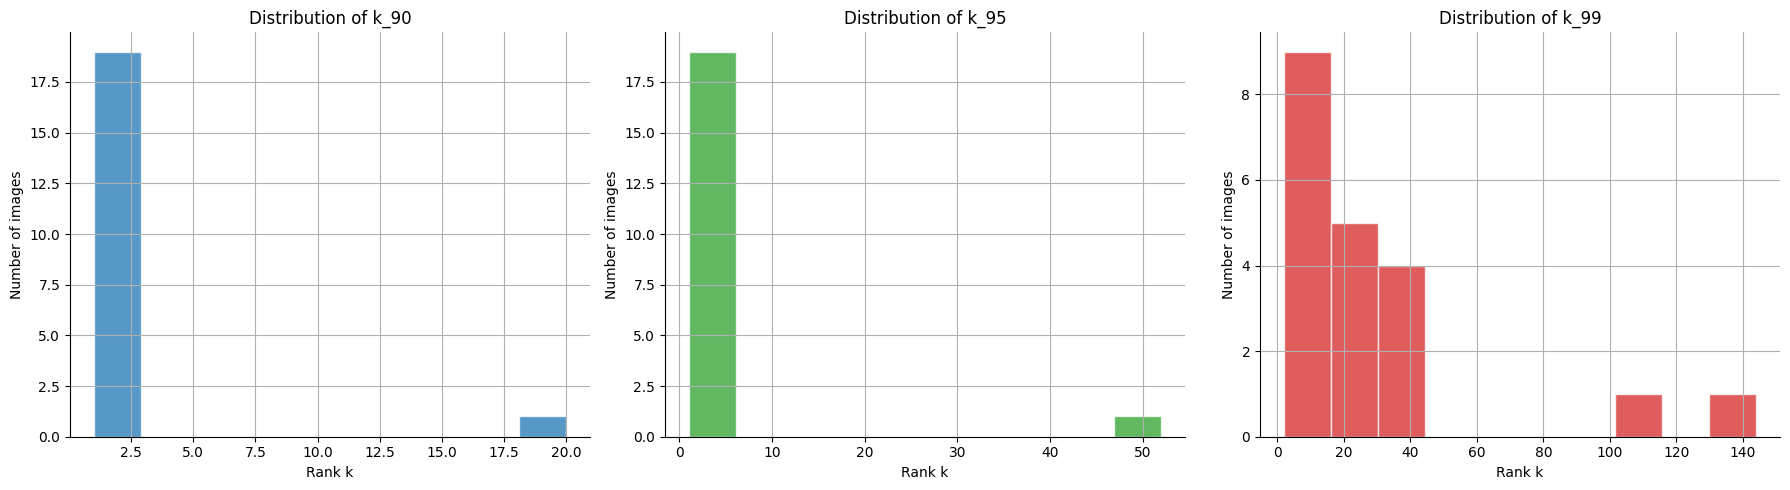

In [33]:
def plot_multiple_image_summary(summary_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, column, color in zip(
        axes,
        ["k_90", "k_95", "k_99"],
        ["tab:blue", "tab:green", "tab:red"],
    ):
        ax.hist(summary_df[column].dropna(), bins=10, color=color, alpha=0.75, edgecolor="white")
        ax.set_title(f"Distribution of {column}")
        ax.set_xlabel("Rank k")
        ax.set_ylabel("Number of images")

    plt.tight_layout()
    plt.show()


plot_multiple_image_summary(multi_image_df)

### --Interpretation

Images with smoother structure should need smaller k because their singular values decay quickly. Images with many edges, repeated patterns, or fine textures should need larger k to reach the same retained-energy thresholds.

Use the dataset-level table and histograms to compare how image content changes low-rank compressibility.

## Reference

| Reference | Topic | Link |
| --- | --- | --- |
| **Trefethen & Bau -- Numerical Linear Algebra** | SVD, matrix norms, rank approximation | ([SIAM][1]) |
| **Golub & Van Loan -- Matrix Computations** | Standard reference for SVD and numerical algorithms | ([Hopkins Press][2]) |
| **Eckart & Young -- The Approximation of One Matrix by Another of Lower Rank** | Original best low-rank approximation theorem | ([Springer][3]) |
| **Mirsky -- Symmetric Gauge Functions and Unitarily Invariant Norms** | Generalization of low-rank approximation to unitarily invariant norms | ([OUP Academic][4]) |

[1]: https://epubs.siam.org/doi/10.1137/1.9780898719574 "Numerical Linear Algebra"
[2]: https://www.press.jhu.edu/books/title/10678/matrix-computations "Matrix Computations | Hopkins Press"
[3]: https://link.springer.com/article/10.1007/BF02288367 "The approximation of one matrix by another of lower rank"
[4]: https://academic.oup.com/qjmath/article-abstract/11/1/50/1525786 "Symmetric Gauge Functions and Unitarily Invariant Norms"